# <center> Лабораторная 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1. 

Для заданного ниже объекта s проделайте следующее:
1. Создайте новый Series, значения которого совпадают со значениями s, а индексы - целочисленные значения от 5 до 20, не включая 20. 
2. Выберите из нового s только целочисленные элементы и вычислите их дисперсию. (\*)

Все полученные результаты округлите до 2-х знаков после запятой.


##### Пояснения:
(\*) Целочисленные значения - значения, имеющие тип int.
- Дисперсия рассчитывается с помощью функции из библиотеки numpy: np.var( , ddof=0) или встроенной в python функции: .var(ddof=1)

In [2]:
s = pd.Series(data=['13', 2, 77.1, 'red', 8, -341, 12.42, '34', 19.02, 72, 1, 87, 12.03, 'green', 0.05], 
              index=range(6, 36, 2))
### Type your code here
s2 = pd.Series(s.values, index = range(5,20))
s2_z = s2[s2.map(type) == int]
np.round(np.var(s2_z), 2), np.round(s2_z.var(ddof=0), 2)


(np.float64(20704.92), np.float64(20704.92))

### Task 2. 
1. Сгенерируйте Series из 100 значений нормально распределённой СВ (np.random.normal с дефолтными параметрами - нулевым средним и единичной дисперсией).
2. Возведите каждое значение серии в 3 степень, а значения индекса увеличьте в 3 раза. 
3. Ответьте на следующие вопросы через запятую (без пробелов) (\*)
    - 1) Выведите сумму элементов, строго меньших 2.6, имеющих чётные значения индекса. 
    - 2) Выведите количество значений серии больше нуля.

#### Пояснения:
 - Определенное значение seed нужно, чтобы ответы у всех выполняющих
это задание были одинаковые и их можно было проверить (так как генерируются
одинаковые series).
 - Следует внимательнее использовать [ ] для выбора данных по нескольким условиям:
либо выбирать данные последовательно, либо сразу по нескольким условиям,
но через оператор &. Отличие оператора and от оператора &: and - выводит
последнее проверенное значение, & - выводит пересечение значений.
Пример: s[ _  &  _ ].sum() 

In [3]:
np.random.seed(242)
### Type your code here
s = pd.Series(np.random.normal(0,1,100))
s**=3
s.index*=3
s[(s<2.6) & (s.index % 2==0)].sum(), (s>0).sum()

(np.float64(-19.455490619511657), np.int64(49))

#### Структура популярного датасета **«Титаник»** выглядит следующим образом:

| Колонка         | Тип данных | Описание                                     |
|-----------------|------------|----------------------------------------------|
| PassengerId     | integer    | Уникальный номер пассажира                   |
| Survived        | integer    | Показатель выживания (0 — погиб, 1 — выжил) |
| Pclass          | integer    | Класс билета (1-й, 2-й, 3-й классы)         |
| Name            | object     | Имя пассажира                                |
| Sex             | object     | Пол пассажира («male» или «female»)         |
| Age             | float      | Возраст пассажира                            |
| SibSp           | integer    | Количество братьев/сестер/супругов на борту |
| Parch           | integer    | Количество родителей/детей на борту         |
| Ticket          | object     | Номер билета                                 |
| Fare            | float      | Стоимость проезда                           |
| Cabin           | object     | Номер каюты (частично отсутствуют данные)   |
| Embarked        | object     | Порт посадки («C», «Q», «S»)                 |



### Task 3.
Используя датасет Titanic, провести Exploratory Data Analysis (EDA) (с помощью описательной статистики), выявить основные факторы, повлиявшие на выживаемость пассажиров, рассчитать долю спасённых мужчин и женщин.

In [4]:
titanic = pd.read_csv(filepath_or_buffer='titanic.csv', index_col= 'PassengerId')

In [5]:
for col in titanic.drop(columns=['Name','Survived','Age','Ticket','Fare','Cabin']):
    display(titanic.groupby(col).Survived.mean())

display(titanic.groupby(pd.cut(titanic.Age, 6),observed=True).Survived.mean())
display(titanic.groupby(pd.qcut(titanic.Fare.dropna(), 6),observed=True).Survived.mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Age
(0.34, 13.683]      0.591549
(13.683, 26.947]    0.354839
(26.947, 40.21]     0.428571
(40.21, 53.473]     0.390000
(53.473, 66.737]    0.348837
(66.737, 80.0]      0.142857
Name: Survived, dtype: float64

Fare
(-0.001, 7.775]      0.205128
(7.775, 8.662]       0.190789
(8.662, 14.454]      0.366906
(14.454, 26.0]       0.436242
(26.0, 52.369]       0.417808
(52.369, 512.329]    0.697987
Name: Survived, dtype: float64


#### Вот таблица, отображающая структуру датасета bank_data.csv:

| Column Name    | Type                 | Description                             |
|----------------|----------------------|-----------------------------------------|
| Client_ID      | int                  | Идентификатор клиента                   |
| Date           | string               | Дата рождения клиента (формат: YYYY-MM-DD) |
| Profession     | category/string      | Профессиональная деятельность клиента   |
| Income         | float                | Годовой доход клиента                    |
| Loan_Balance   | float                | Текущий остаток по кредиту               |
| Gender         | category/string      | Пол клиента ("Male"/"Female")           |


### Task 4.
Загрузите данные из файла 'bank_data.csv'. Проверьте структуру загруженных данных: выведите первые 5 записей и размеры таблицы (строки x столбцы).Посчитайте общее число клиентов банка и количество уникальных профессий среди клиентов.
Проверить наличие пропусков в данных и заполнить пустые значения средней величиной соответствующего столбца.


In [6]:
data = pd.read_csv(filepath_or_buffer='bank_data.csv', index_col='Client_ID')

display(data.head())
print(data.shape)

print('Number of clients:',data.index.nunique())
print('Unique Professions:', data.Profession.nunique())

display(data.isna().sum())
data.fillna(data.select_dtypes(include='number').mean(), inplace=True)

display(data.head())
display(data.isna().sum())

,Date,Profession,Income,Loan_Balance,Gender
Client_ID,,,,,
1,1960-01-01,Doctor,51640.921919,11493.764542,Male
2,1960-01-15,Engineer,NaN,6241.044750,Female
3,1960-01-30,Designer,NaN,7868.212019,Male
4,1960-02-14,Engineer,53358.260364,15742.228546,Female
5,1960-02-29,Engineer,38142.883168,10566.352053,Female


(1000, 5)
Number of clients: 1000
Unique Professions: 5


Date             0
Profession       0
Income          50
Loan_Balance     0
Gender           0
dtype: int64

,Date,Profession,Income,Loan_Balance,Gender
Client_ID,,,,,
1,1960-01-01,Doctor,51640.921919,11493.764542,Male
2,1960-01-15,Engineer,51144.823989,6241.044750,Female
3,1960-01-30,Designer,51144.823989,7868.212019,Male
4,1960-02-14,Engineer,53358.260364,15742.228546,Female
5,1960-02-29,Engineer,38142.883168,10566.352053,Female


Date            0
Profession      0
Income          0
Loan_Balance    0
Gender          0
dtype: int64

### Task 5.
Преобразуйте строку 'Date' в тип datetime и извлеките из нее год, месяц и день рождения клиентов отдельно в новые столбцы.
Отфильтруйте записи клиентов старше 30 лет и подсчитайте средний доход для этой выборки.
Проведите группировку клиентов по профессиям и вычислите среднюю сумму кредита для каждой профессии.
Для всех кредитных сумм выполните стандартизацию (приведение к нормальному распределению).
Удалите ненужные столбцы и преобразуйте категорию профессии в числовой вид (one-hot encoding).
Сохраните обработанные данные в новый CSV-файл для дальнейшего использования в обучении нейронных сетей.

In [7]:
data.Date = pd.to_datetime(data.Date)
data['Year'] = data.Date.dt.year
data['Month'] = data.Date.dt.month
data['Day'] = data.Date.dt.day
data

today = pd.Timestamp.today()
age = today.year - data.Year - (
    (today.month < data.Month) |
    ((today.month == data.Month) & (today.day < data.Day))
)
data['Age'] = age

print('Avg Income older 30:', data[data.Age>30].Income.mean())

display(data.groupby('Profession').Loan_Balance.mean())

data['Loan_Balance_norm'] = (data['Loan_Balance'] - data['Loan_Balance'].mean()) / data['Loan_Balance'].std()

data_encode = pd.get_dummies(data, columns=['Profession'],dtype=int)
data_encode.drop(columns=['Date','Loan_Balance','Age'],inplace=True)
data_encode.to_csv('bank_data_encode.csv')
data_encode

Avg Income older 30: 51321.52042607197


Profession
Designer      9918.913324
Developer     9994.977918
Doctor       10512.587489
Engineer     10112.137794
Manager       9916.911214
Name: Loan_Balance, dtype: float64

,Income,Gender,Year,Month,Day,Loan_Balance_norm,Profession_Designer,Profession_Developer,Profession_Doctor,Profession_Engineer,Profession_Manager
Client_ID,,,,,,,,,,,
1,51640.921919,Male,1960,1,1,0.287075,0,0,1,0,0
2,51144.823989,Female,1960,1,15,-0.790704,0,0,0,1,0
3,51144.823989,Male,1960,1,30,-0.456834,1,0,0,0,0
4,53358.260364,Female,1960,2,14,1.158797,0,0,0,1,0
5,38142.883168,Female,1960,2,29,0.096784,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
996,26552.137870,Male,2000,11,1,-1.186604,0,1,0,0,0
997,51144.823989,Male,2000,11,16,-0.226138,0,0,0,0,1
998,48832.442045,Female,2000,12,1,-0.026113,0,0,0,0,1


#### Информация для последующих заданий
- Для всех последующих заданий будем использовать обезличенные транзакционные банковские данные. Для этого считайте в переменные tr_mcc_codes, tr_types, transactions и gender_train из одноимённых таблиц из папки data. Для таблицы transactions используйте только первые n=1000000 строк. Обратите внимание на разделители внутри каждого из файлов - они могут различаться!

In [8]:
### Type your code here
tr_mcc_codes = pd.read_csv(filepath_or_buffer='tr_mcc_codes.csv',index_col='mcc_code',sep=';')
tr_types = pd.read_csv(filepath_or_buffer='tr_types.csv',index_col='tr_type',sep=';')
transactions = pd.read_csv(filepath_or_buffer='transactions.csv',nrows=10**6, index_col='customer_id')
gender_train = pd.read_csv(filepath_or_buffer='gender_train.csv',index_col='customer_id')


#### Описание данных
#### Таблица ```transactions.csv```
##### Описание
Таблица содержит историю транзакций клиентов банка за один год и три месяца.

##### Формат данных

```
customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
111111,15 01:40:52,1111,1000,-5224,111111
111112,15 15:18:32,3333,2000,-100,11122233
...
```
##### Описание полей

 - ```customer_id``` — идентификатор клиента;
 - ```tr_datetime``` — день и время совершения транзакции (дни нумеруются с начала данных);
 - ```mcc_code``` — mcc-код транзакции;
 - ```tr_type``` — тип транзакции;
 - ```amount``` — сумма транзакции в условных единицах со знаком; ```+``` — начисление средств клиенту (приходная транзакция), ```-``` — списание средств (расходная транзакция);
 - ```term_id``` — идентификатор терминала;


#### Таблица ```gender_train.csv```

##### Описание
Данная таблица содержит информацию по полу для части клиентов, для которых он известен. Для остальных клиентов пол неизвестен.

##### Формат данных
```
customer_id,gender
111111,0
111112,1
...
```

##### Описание полей
 - ```customer_id``` — идентификатор клиента;
 - ```gender``` — пол клиента;

#### Таблица ```tr_mcc_codes.csv```

##### Описание
Данная таблица содержит описание mcc-кодов транзакций.

##### Формат данных
```
mcc_code;mcc_description
1000;словесное описание mcc-кода 1000
2000;словесное описание mcc-кода 2000
...
```

##### Описание полей
 - ```mcc_code``` – mcc-код транзакции;
 - ```mcc_description``` — описание mcc-кода транзакции.

#### Таблица ```tr_types.csv```

##### Описание
Данная таблица содержит описание типов транзакций.

##### Формат данных
```
tr_type;tr_description
1000;словесное описание типа транзакции 1000
2000;словесное описание типа транзакции 2000
...
```

##### Описание полей
 - ```tr_type``` – тип транзакции;
 - ```tr_description``` — описание типа транзакции;

In [9]:
### Type your code here


### Task 6.
1. В датафрейме transactions задайте столбец  customer_id в качестве индекса.
2. Выделите клиента с максимальной суммой транзакции (то есть с максимальным приходом на карту). (\*)
3. Найдите у него наиболее часто встречающийся модуль суммы приходов/расходов. (\**)


##### Выберите все верные пункты:
    - 1) 1122957.89
    - 2) 15721.41
    - 3) 22459.16
    - 4) 13475494.63
    - 5) 107407.78
    - 6) 65019.26

##### Пояснения:
(\*) Если у клиента были транзакции [-10000, 10, 0, -10], то максимумом будет являться значение 10. <br>
(\**) Если у клиента были транзакции [-10000, 10, 0, -10], то наиболее встречающийся модуль суммы транзакций равен 10, и встретился он 2 раза.

In [10]:
### Type your code here
id_max_amount = transactions.amount.idxmax()
transactions.loc[id_max_amount,'amount'].abs().mode()

0    22459.16
Name: amount, dtype: float64

### Task 7.
Считайте в переменные tr_mcc_codes, tr_types, transactions и customers_gender_train. В transactions считайте только первые 1000000 строк. Соедините transactions со всеми остальными таблицами (tr_mcc_codes, tr_types, gender_train). Причём с customers_gender_train необходимо смёрджиться с помощью left join, а с оставшимися датафреймами - через inner. После получения результата таблицы gender_train, tr_types, tr_mcc_codes можно удалить. В результате соединения датафреймов должно получиться 999584 строки. Выделите из поля tr_datetime относительный день tr_day (первое число до точного времени). 

1. Разбейте расходы (отрицательные значения сумм) на 5 бакетов amount_bucket равного объёма (с помощью pd.qcut), разбив все траты на категории 'Very High', 'High', 'Middle', 'Low', 'Very Low'. (\*)
2. Оставшиеся неотрицательные траты отнесите к категории 'Income'.
(воспользуйтесь функцией .cat.add_categories('Income') для того, чтобы добавить новую категорию 'Income' к категориям 'Very High', 'High', 'Middle', 'Low', 'Very Low', а затем заполните пустые значения новой категорией).
3. Из поля tr_datetime выделите час tr_hour, в который произошла транзакция, как первые 2 цифры до ":". (\**)
3. После этого постройте сводную таблицу, значениями в которой является пол gender, индексы - tr_hour, столбцы - amount_bucket.
4. Отрисуйте полученные результаты в виде тепловой карты, передав их в созданную функцию plot_pivot_table.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
     Ответ :да
     2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
     Ответ :нет
     3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
     Ответ :нет информации
     4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
     Ответ :да
     5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.
     Ответ :нет

##### Пояснения:
(\*) Обратите внимание, что в категории Very High Должны оказаться максимальные по модулю отрицательные транзакции. <br>
(\**) Например, для строки "0 10:23:26" час будет равен 10, а для строки "6 07:08:31"- 07. Можно воспользоваться функциями str.split() или str.find() и 
функцией .apply(lambda x: x[])

,tr_datetime,mcc_code,tr_type,amount,term_id,mcc_description,tr_description,gender,tr_hour,amount_bucket
customer_id,,,,,,,,,,
39026145,0 10:23:26,4814,1030,-2245.92,NaN,"Звонки с использованием телефонов, считывающих...",Оплата услуги. Банкоматы СБ РФ,NaN,10,Very Low
39026145,1 10:19:29,6011,7010,56147.89,NaN,Финансовые институты — снятие наличности автом...,Взнос наличных через АТМ (в своем тер.банке),NaN,10,Income
39026145,1 10:20:56,4829,2330,-56147.89,NaN,Денежные переводы,Списание с карты по операции “перевода с карты...,NaN,10,Very High
39026145,1 10:39:54,5499,1010,-1392.47,NaN,"Различные продовольственные магазины — рынки, ...",Покупка. POS ТУ СБ РФ,NaN,10,Very Low
39026145,2 15:33:42,5499,1010,-920.83,NaN,"Различные продовольственные магазины — рынки, ...",Покупка. POS ТУ СБ РФ,NaN,15,Very Low
...,...,...,...,...,...,...,...,...,...,...
98801178,269 10:29:06,5921,1010,-23016.59,127873,Магазины с продажей спиртных напитков на вынос...,Покупка. POS ТУ СБ РФ,NaN,10,High
98801178,270 10:26:45,5211,1010,-61380.88,10114209,Лесо- и строительный материал,Покупка. POS ТУ СБ РФ,NaN,10,Very High
98801178,270 15:18:53,5921,1010,-11800.27,10105341,Магазины с продажей спиртных напитков на вынос...,Покупка. POS ТУ СБ РФ,NaN,15,Middle


<Axes: xlabel='amount_bucket', ylabel='tr_hour'>

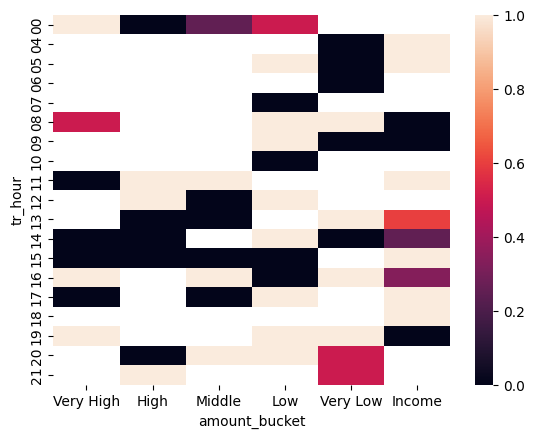

In [11]:

transactions_merged = pd.merge(transactions.reset_index(), tr_mcc_codes, on='mcc_code')
transactions_merged = pd.merge(transactions_merged, tr_types, on='tr_type')
transactions_merged = pd.merge(transactions_merged, gender_train,left_index=True, right_index=True, how='left')

tr_day = transactions_merged.tr_datetime.str.split().apply(lambda x: x[0])
tr_hour =transactions_merged.tr_datetime.str.split().apply(lambda x: x[1][0:2])

amount_bucket = pd.qcut(transactions_merged.amount[transactions_merged.amount<0],5,
                        labels=['Very High', 'High', 'Middle', 'Low', 'Very Low'])
amount_bucket = amount_bucket.cat.add_categories('Income')
amount_bucket = amount_bucket.reindex(transactions_merged.index, fill_value='Income')

transactions_merged['tr_hour'] = tr_hour
transactions_merged['amount_bucket'] = amount_bucket
table = transactions_merged.pivot_table(index='tr_hour', columns='amount_bucket',values= 'gender',observed=False)

transactions_merged.set_index('customer_id',inplace=True)
display(transactions_merged)
def plot_pivot_table():
    return sns.heatmap(table)
plot_pivot_table()

### Task 8.
1. Измените тип поля tr_day на int.
2. Выберите из transactions все MCC коды, которые встретились в выборке более чем 60000 раз.
3. Сгруппируйте отфильтрованный датафрейм по дню и MCC-коду, получая средние значения суммы amount.  
4. Далее отрисуйте зависимость средних сумм (может пригодится метод unstack()) по каждому из MCC-кодов по дням.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) 2 из полученных MCC-кодов связаны с финансовыми институтами
     Ответ: да
     2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
     Ответ: да
     3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
     Ответ: нет
     4) Денежные переводы имеют как минимум 3 явных минимума средних
     Ответ: да
     5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию. 
     Ответ: нет

,mcc_description
mcc_code,
4814,"Звонки с использованием телефонов, считывающих..."
6011,Финансовые институты — снятие наличности автом...
4829,Денежные переводы
6010,Финансовые институты — снятие наличности вручную
5411,"Бакалейные магазины, супермаркеты"


mcc_code
6010   -591776.070091
4829   -199376.639904
6011   -130133.804520
5411    -15013.402303
4814     -5413.488492
Name: amount, dtype: float64

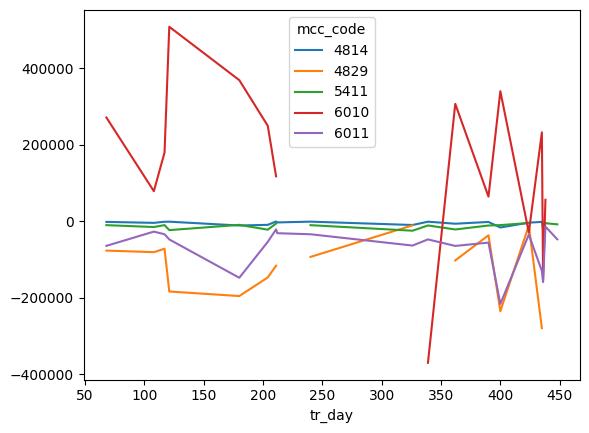

In [12]:
tr_day = tr_day.map(int)
transactions_merged['tr_day'] = tr_day
codes = transactions.mcc_code.value_counts()[lambda x: x > 60000].index
filtered = transactions_merged[transactions_merged.mcc_code.isin(codes)]
avg_amount = filtered.groupby(['tr_day', 'mcc_code']).amount.mean()
avg_amount.unstack().plot()

display(filtered[['mcc_code','mcc_description']].set_index('mcc_code').drop_duplicates())
filtered[filtered.amount<0].groupby('mcc_code').amount.mean().sort_values()


### Task 9:
Считайте данные из файла 'winemag-data-130k-v2.csv'. 
а) Постройте точечный график (Scatter plot), по оси х отложите points, а по y - price.
б) Постройте график Barplot количества вин по странам.

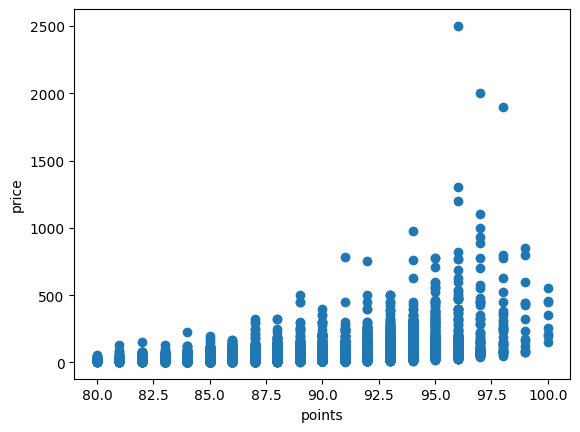

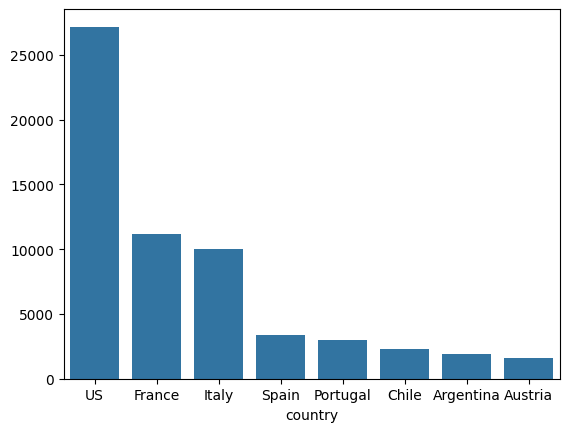

country
Argentina                  1907
Armenia                       1
Australia                  1177
Austria                    1635
Bosnia and Herzegovina        1
Brazil                       31
Bulgaria                     68
Canada                      108
Chile                      2258
Croatia                      44
Cyprus                        6
Czech Republic                6
England                      36
France                    11174
Georgia                      37
Germany                    1051
Greece                      242
Hungary                      61
India                         4
Israel                      259
Italy                     10005
Lebanon                      20
Luxembourg                    4
Macedonia                     6
Mexico                       31
Moldova                      30
Morocco                      11
New Zealand                 733
Peru                          8
Portugal                   2963
Romania                      67


In [13]:
winemag = pd.read_csv(filepath_or_buffer='winemag-data-130k-v2.csv', index_col=0)
plt.scatter(winemag.points, winemag.price)
plt.xlabel('points')
plt.ylabel('price')
plt.show()
sns.barplot(winemag.groupby('country').size().sort_values(ascending=False).head(n=8))
plt.show()
winemag.groupby('country').size()